In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# sigma_t^2 = alpha_0,st + alpha_1,st * y_{t-1}^2 + beta_1s * sigma_{t-1}^2

np.random.seed(42)

T = 500
k = 2

g_alpha_0 = np.array([0.05, 0.20])
g_alpha_1 = np.array([0.10, 0.40])
g_beta_1 = np.array([0.80, 0.50])

P = np.array([
    [0.99, 0.01],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)
sigma2 = np.zeros(T)

states[0] = np.random.choice(k)
s_init = states[0]

sigma2[0] = g_alpha_0[s_init] / (1 - g_alpha_1[s_init] - g_beta_1[s_init])
y[0] = np.random.normal(loc=0, scale=np.sqrt(sigma2[0]))

for t in range(1, T):
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    sigma2[t] = g_alpha_0[s] + g_alpha_1[s]*(y[t-1]**2) + g_beta_1[s]*sigma2[t-1]

    y[t] = np.random.normal(loc=0, scale=np.sqrt(sigma2[t]))

    if t % 100 == 0:
        print(f"t={t:<5} State: {s:<3} Sigma^2: {sigma2[t]:>6.2f}  y: {y[t]:>6.2f}")


t=100   State: 0   Sigma^2:   0.50  y:  -0.01
t=200   State: 0   Sigma^2:   0.59  y:   1.11
t=300   State: 0   Sigma^2:   0.54  y:  -0.01
t=400   State: 0   Sigma^2:   0.44  y:   0.22


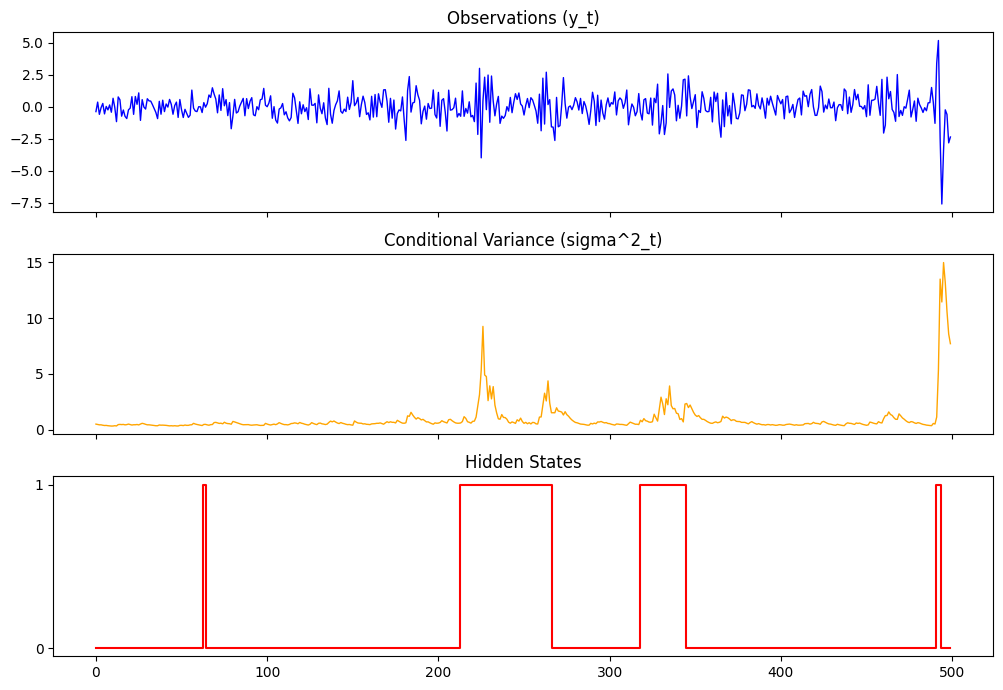

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

ax1.plot(y, color='blue', linewidth=1)
ax1.set_title("Observations (y_t)")

# Plotting sigma2 instead of var
ax2.plot(sigma2, color='orange', linewidth=1)
ax2.set_title("Conditional Variance (sigma^2_t)")

ax3.plot(states, color='red', drawstyle='steps-mid')
ax3.set_title("Hidden States")
ax3.set_yticks([0, 1])

plt.tight_layout()
plt.show()